# Visualizaciones de datos

In [3]:
import pandas as pd

## Grafica de barras

* Magnitud vs proporción

Es recomendable para cambios de magnitud para valores absolutos

Donde no podría usar una grafica de barras:

* Cuando tengamos muchas categorías a comparar
* Si quiero analizar riesgos individuales de un dataset y existan muchos registros
* Si quiero comparar proporciones (se podría usar graficas de pastel o de otro tipo)
* Si me interesa investigar acerca de la distribución de mis datos

In [6]:
df  = pd.read_csv('datasets/titanic-barras.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
len(df)

891

### Ejercicio

* Objetivo: Visualizar cuantos pasajeros hombres y cuantas pasajeras mujeres habian en el titanic

In [20]:
agrupados_pasajeros =df.groupby('Sex').agg({'PassengerId':'count'})

agrupados_pasajeros

,PassengerId
Sex,
female,314
male,577


### usando pandas

<Axes: title={'center': 'Cantidad de pasajeros por sexo'}, xlabel='Sex'>

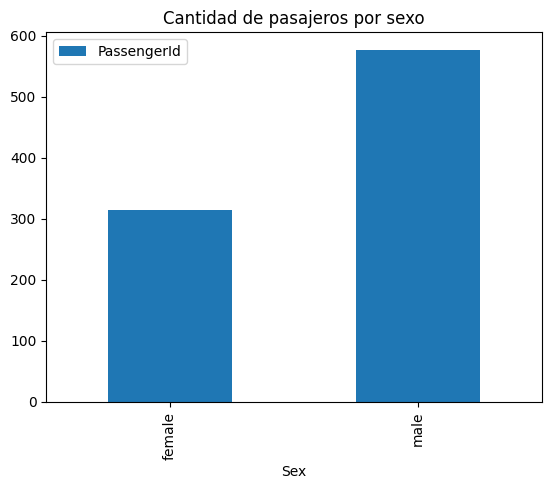

In [14]:
agrupados_pasajeros.plot.bar(
    y = 'PassengerId',
    title = 'Cantidad de pasajeros por sexo',
    width = 0.5
)

### Usando Seaborn

In [15]:
import seaborn as sns

* Seaborn no identifica el data frame directamente, es decir, se debe procesar el DF para que use únicamente columnas, no puede usar directamente los index como lo usa Pandas

In [21]:
pasajeros = agrupados_pasajeros.reset_index()
pasajeros

,Sex,PassengerId
0,female,314
1,male,577


<Axes: xlabel='Sex', ylabel='PassengerId'>

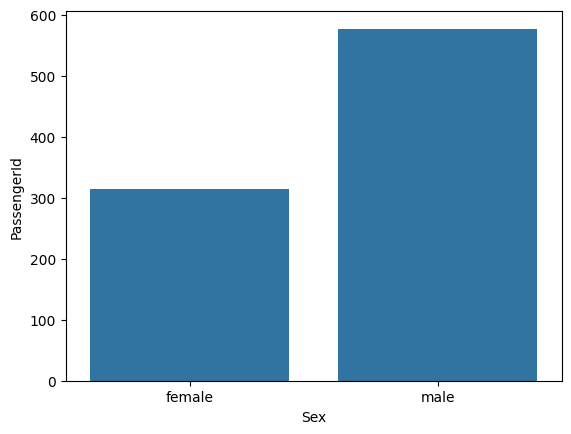

In [23]:
sns.barplot(
    pasajeros,
    x = 'Sex',
    y = 'PassengerId'
)

### Usando Matplotlib

In [24]:
import matplotlib.pyplot as plt

<BarContainer object of 2 artists>

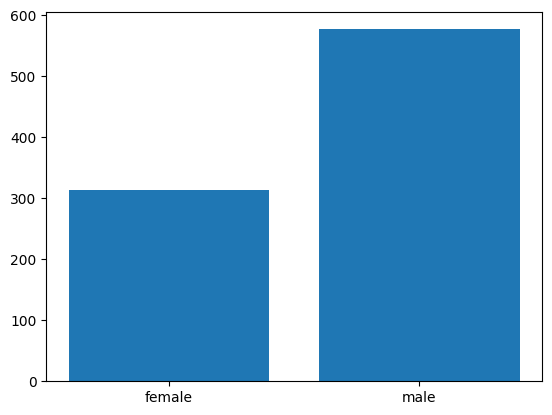

In [25]:
plt.bar(
    pasajeros['Sex'],
    pasajeros['PassengerId']
)

### Grafico de Pastel

#Summary:
Representa una parte porcentual de un todo, es decir, se recomienda usar únicamente en realizar una comparación de una parcentual de un todo. NO SE USA cuando se requiera comparar magnitudes.

In [19]:
import pandas as pd

df = pd.read_csv('datasets/titanic-barras.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
pasajeros = df.groupby('Sex').agg({'PassengerId':'count'})

pasajeros

,PassengerId
Sex,
female,314
male,577


<Axes: >

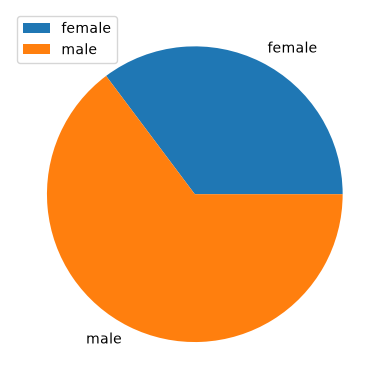

In [3]:

pasajeros.plot.pie(
    y = 'PassengerId')

In [16]:
import plotly.express as px

In [5]:
pasajeros2 = pasajeros.reset_index()

In [6]:
figura = px.pie(
    pasajeros2,
    names = 'Sex',
    values = 'PassengerId',
    title = 'Cantidad de pasajeros por sexo'
)

figura.show()

### Ejercicio

* Objetivo: Visualizar qué proporción de pasajeros viajaba en cada clase del Titanic (`Pclass`: 1ra, 2da, 3ra), usando un gráfico de pastel o de dona.

Ten en cuenta la definición vista arriba: el pastel/dona sirve para mostrar **partes de un todo en porcentaje**, no para comparar magnitudes absolutas. `Pclass` es un buen candidato porque tiene pocas categorías (3) y lo que interesa es qué parte del total representa cada una — a diferencia de columnas como `Fare` o `Age`, donde no aplicaría.


### Solución

Agrupamos primero los datos que necesitamos, en este caso, agrupamos que pasajeros viajaba en cada clase del Titanic

In [20]:
pasajeros_clase = df.groupby('Pclass').agg({
    'PassengerId': 'count'
}).reset_index()
pasajeros_clase

,Pclass,PassengerId
0,1,216
1,2,184
2,3,491


Si notamos, "Pclass" los valores que tiene son muy simples, es decir, son valores númericos sin nigún sentido para personas que no conozcan la DB (dataset en este caso), por lo tanto, agregamos una nueva columna al data frame que creamos (`pasajeros_clase`) donde hacemos un `.map` para identificar cada valor de la columna `Pclass` y darle un valor más sencillo de leer como se muestra en la columna `clase_label`.

In [22]:
pasajeros_clase['clase_label'] = pasajeros_clase['Pclass'].map({
    1: '1ra clase',
    2: '2da clase',
    3: '3ra clase'
})

De esta manera, los nombres que vamos a usar son de la columna nueva que creamos (`clase_label`) y los valores que usaremos será `PassengerId`. Por lo tanto, así queda nuestra grafica de Pie

In [23]:
figura_clase = px.pie(
    pasajeros_clase,
    names = 'clase_label',
    values = 'PassengerId',
    title = 'Proporción de pasajeros del Titanic por clase'
)

figura_clase.show()

Como adicional haremos la gráfica de dona

In [24]:
figura_clase = px.pie(
    pasajeros_clase,
    names = 'clase_label',
    values = 'PassengerId',
    title = 'Proporción de pasajeros del Titanic por clase',
    hole = 0.70 #es un parametro que permite hacer un gráfico de dona, si se pone 0 es un gráfico de pastel, si se pone 0.5 es un gráfico de dona más grande
)

figura_clase.show()

# Grafica de Cajones

Funciona para poder comparar diversos grupos a través de sus estadísticos (media, mediana y cuartiles). Un segundo uso también es revisar si existen datos aberrantes dentro de mis variables o dentro de alguna categoría.

Además, este tipo de gráfico no me dice la `forma` exacta de la `distribución` de mis datos.

### Ejercicio
Encontrar información acerca de las diferencias de edades entre los pasajeros hombres y mujeres

In [25]:
import pandas as pd

df_cajones = pd.read_csv('datasets/titanic-barras.csv')
df_cajones.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
df_cajones['Age'].isna().sum()

np.int64(177)

In [27]:
# Eliminar filas con valores nulos en la columna 'Age'
df_cajones = df_cajones.dropna(subset=['Age'], axis='index')
df_cajones

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [32]:
import matplotlib.pyplot as plt

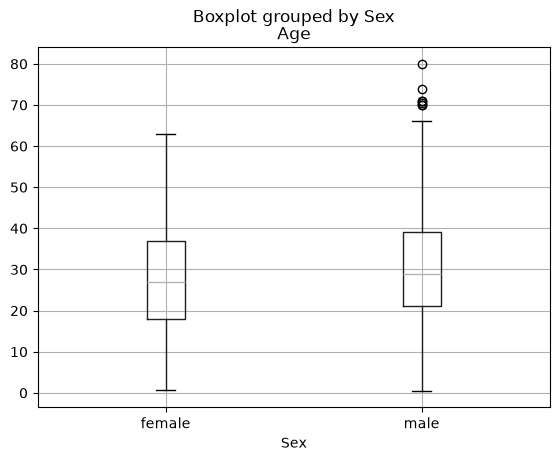

In [34]:
df_cajones.boxplot(
    column='Age',
    by = 'Sex'
)

plt.show()

In [35]:
import seaborn as sns

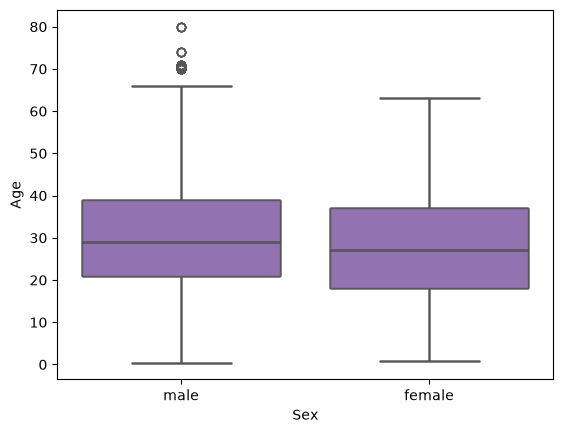

In [40]:
sns.boxplot(
    df_cajones,
    x = 'Sex',
    y = 'Age'
)

plt.show()

# Grafico de Violines

1. No ayuda a poder mostrar cual sería la distribución correcta de nuestros datos.
2. Se utiliza cuando se requiere ver o comprar la forma de la distribución de los datos entre diferentes grupos y al mismo tiempo comparar estadisticos

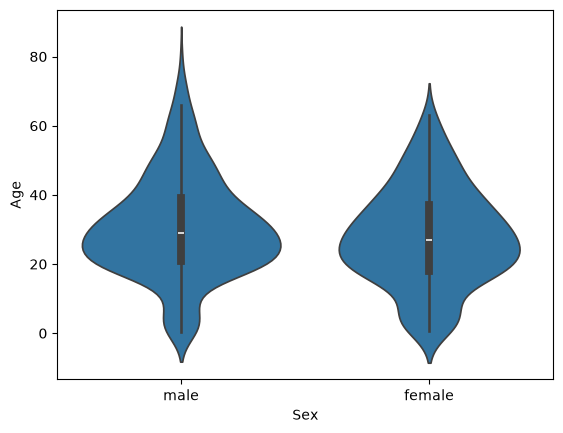

In [41]:
sns.violinplot(
    df_cajones,
    x = 'Sex',
    y = 'Age'
)

plt.show()